In [8]:
pip install --upgrade numpy

Codice per simulare la Polynomial Chaos expansion

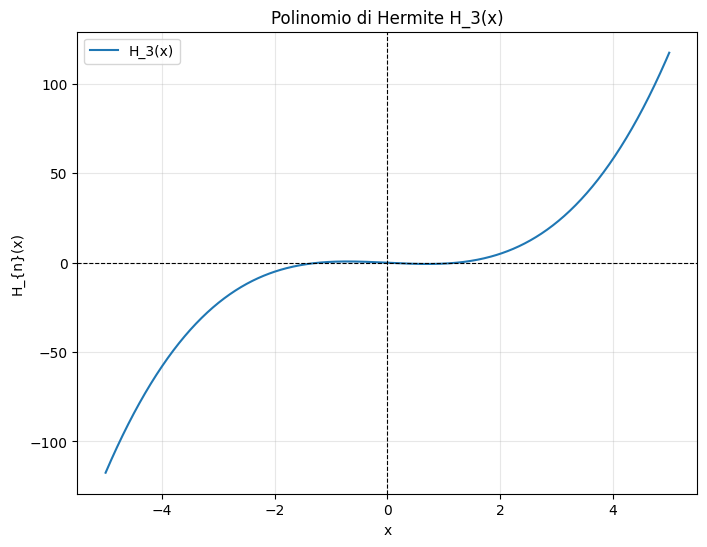

In [1]:
#plot olinomio di Hermite
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite

def plot_hermite_polynomial(n):
    # Calcola il polinomio di Hermite di grado n
    Hn = hermite(n)
    
    # Genera valori x per il grafico
    x = np.linspace(-5, 5, 500)
    
    # Calcola i valori del polinomio su x
    y = Hn(x)/pow(2,n)
    # Crea il grafico
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, label=f"H_{n}(x)")
    plt.title(f"Polinomio di Hermite H_{n}(x)")
    plt.xlabel("x")
    plt.ylabel("H_{n}(x)")
    plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
    plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# Esempio: calcola e disegna il 5° polinomio di Hermite
plot_hermite_polynomial(3)

-0.00032200209636536707
1.0028906368753996


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21732\2582962649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


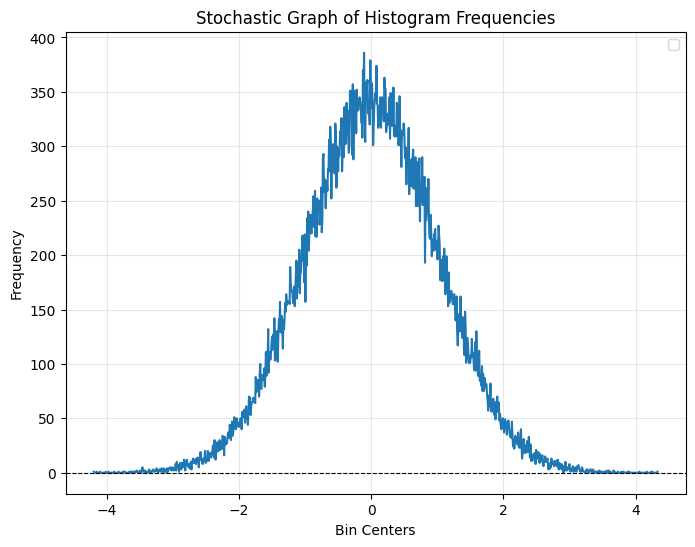

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Extract 100 samples from a standard normal distribution
samples = np.random.normal(loc=0, scale=1, size=100000)

# Calculate the histogram bins and frequencies
frequencies, bin_edges = np.histogram(samples, bins=1000)

print(np.mean(samples))
print(np.var(samples))
# Compute the bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot the frequencies as a stochastic graph
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, frequencies, alpha=1)
plt.title("Stochastic Graph of Histogram Frequencies")
plt.xlabel("Bin Centers")
plt.ylabel("Frequency")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

the expected mean is 1.4 while the statistical mean is 1.2879571317240501
the expected variance is 1.3209840000000002 while the statistical variance is 1.527683473265549


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21732\1503834585.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


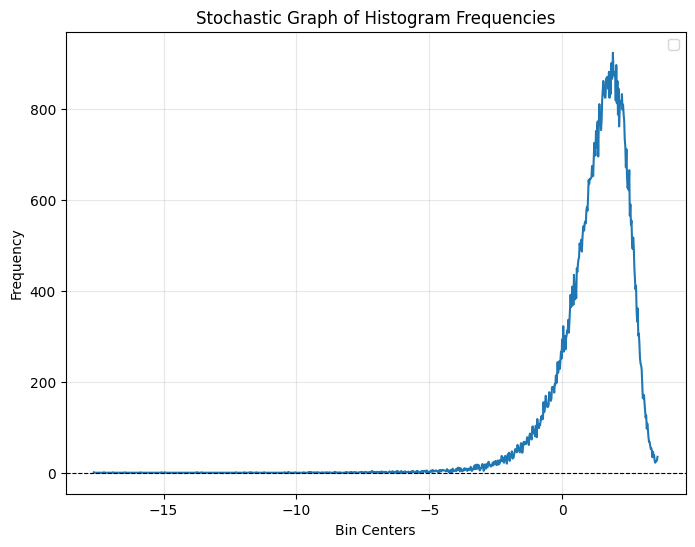

In [14]:
#plot olinomio di Hermite
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sp
from scipy.special import hermite

a=[1.4, 1.1, -0.22, 0.04, -0.009, 0.004, -0.001]
H=[]
for i in range(len(a)):
    H.append(hermite(i))

samples = np.random.normal(loc=0, scale=1, size=100000)

a_samples=[]
for i in range(len(samples)):
    a_samples.append(0)
    for j in range(len(a)):
        a_samples[i]+=a[j]*H[j](samples[i])/pow(2,j)

# Calculate the histogram bins and frequencies
frequencies, bin_edges = np.histogram(a_samples, bins=1000)

print("the expected mean is", a[0],"while the statistical mean is", np.mean(a_samples))
expected_variance = 0
for i in range(1,len(a)):
    expected_variance+=math.factorial(i)*(a[i]**2)
print("the expected variance is", expected_variance,"while the statistical variance is", np.var(a_samples))

# Compute the bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# Plot the frequencies as a stochastic graph
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, frequencies, alpha=1)
plt.title("Stochastic Graph of Histogram Frequencies")
plt.xlabel("Bin Centers")
plt.ylabel("Frequency")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.grid(alpha=0.3)
plt.legend()
plt.show()